In [2]:
# ============================================================
# الخلية 1: المكتبات والإعدادات (نسخة Jupyter المحلية)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os, re, time, math, warnings
from scipy.linalg import sqrtm, inv
from scipy.stats import kurtosis, skew, entropy, ttest_ind
from scipy.interpolate import griddata
from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (16, 6)
sns.set_style('whitegrid')

# ── إعدادات الشبكة ───────────────────────────────────────────
ROWS, COLS         = 34, 16
CENTER_ROW         = 16.5
CENTER_COL         = 7.5
RADIUS             = 6.0
EPS                = 1e-10
WEIGHT_THRESHOLD   = 0.01
STABLE_WINDOW_TRIM = 0.20

# ── القناع الدائري ────────────────────────────────────────────
_ri, _ci = np.indices((ROWS, COLS))
MASK_2D  = np.sqrt((_ri - CENTER_ROW)**2 + (_ci - CENTER_COL)**2) <= RADIUS
N_ACTIVE_PIXELS = int(MASK_2D.sum())

# ── إحداثيات ثابتة (تُحسب مرة واحدة) ────────────────────────
_y_idx, _x_idx = np.indices((ROWS, COLS))
COORDS_FLAT     = np.stack([_x_idx.ravel(), _y_idx.ravel()], axis=0).astype(float)

print(f"✅ الإعدادات جاهزة — عدد البكسلات النشطة في الحساس: {N_ACTIVE_PIXELS}")

✅ الإعدادات جاهزة — عدد البكسلات النشطة في الحساس: 112


In [3]:
# ============================================================
# الخلية 2: دوال معالجة وتنظيف الإشارات
# ============================================================
def apply_energy_normalization(frame_2d):
    e = np.clip(frame_2d, 0, None)
    s = np.sum(e)
    return e / s if s > 0 else e

def apply_whitening_transform(energy_map):
    rows, cols   = energy_map.shape
    coords       = np.stack([np.arange(cols * rows) % cols,
                              np.arange(cols * rows) // cols], axis=0).astype(float)
    weights      = energy_map.ravel()
    total_weight = np.sum(weights)

    if total_weight <= 0:
        return energy_map

    mean_pos = np.sum(coords * weights, axis=1, keepdims=True) / total_weight
    centered = coords - mean_pos
    cov      = (centered * weights) @ centered.T / total_weight
    cov      = (cov + cov.T) / 2

    try:
        W       = inv(sqrtm(cov + np.eye(2) * 1e-6))
        wc      = W @ centered
        wx, wy  = wc[0], wc[1]

        def rescale(arr, lo, hi):
            a, b = arr.min(), arr.max()
            if a == b: return np.full_like(arr, (lo + hi) / 2)
            return (arr - a) / (b - a) * (hi - lo) + lo

        wx_s   = rescale(wx, 0, cols - 1)
        wy_s   = rescale(wy, 0, rows - 1)
        gy, gx = np.mgrid[0:rows, 0:cols]
        w_map  = griddata(np.stack([wx_s, wy_s], axis=1),
                          weights, (gx, gy),
                          method='linear', fill_value=0.0)
        return np.clip(w_map, 0, None)

    except Exception as e:
        warnings.warn(f"Whitening failed: {e}")
        return energy_map

def apply_zscore_normalization(energy_map):
    mean_v = np.mean(energy_map)
    std_v  = np.std(energy_map)
    z      = (energy_map - mean_v) / (std_v if std_v > 0 else 1.0)
    z      = z - np.min(z)
    s      = np.sum(z)
    return z / s if s > 0 else z

print("✅ دوال التنظيف (Pipeline) جاهزة")

✅ دوال التنظيف (Pipeline) جاهزة


In [4]:
# ============================================================
# الخلية 3: دوال المساعدة
# ============================================================
_COND_PATTERN = re.compile(r'[-_]?[FMfm][-_]?([LN])\d*$|[-_]([LN])\d*$')

def parse_condition(filepath):
    name  = os.path.basename(filepath).upper().replace('.CSV', '')
    match = _COND_PATTERN.search(name)
    if not match: return None
    letter = match.group(1) or match.group(2)
    return 'Normal' if letter == 'N' else 'Low Iron'

def top_n_energy(sorted_desc, total, pct):
    k = max(1, int(np.ceil(len(sorted_desc) * pct)))
    return np.sum(sorted_desc[:k]) / (total + EPS)

print("✅ دوال المساعدة جاهزة")

✅ دوال المساعدة جاهزة


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# ============================================================
# الخلية 4: استخراج الميزات بسرعة خارقة مع طباعة الملفات (نسخة Threading)
# ============================================================
from joblib import Parallel, delayed
import time
import datetime
import glob, os
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew, entropy

folder_path = '/content/drive/MyDrive/rawData'
csv_files   = glob.glob(os.path.join(folder_path, "*.csv"))

if len(csv_files) == 0:
    print("❌ لم يتم العثور على أي ملفات! تأكدي من المسار.")
else:
    print(f"🚀 ممتاز! تم العثور على {len(csv_files)} ملف.")
    print("⚡ بدء تشغيل المعالجات المتوازية (ستظهر الملفات هنا مباشرة)...\n")
    start_time = time.time()

    def process_single_file(file):
        # طباعة اسم الملف فور بدء معالجته (الآن ستظهر في جوبيتر فوراً)
        print(f"🔄 جاري معالجة: {os.path.basename(file)} ...")

        file_dataset = []
        condition = parse_condition(file)
        if condition is None: return file_dataset

        try:
            df = pd.read_csv(file, on_bad_lines='skip')
            for idx in range(len(df)):
                delta_str = (str(df['delta_values'].iloc[idx]).replace('OK 34 16', '').replace('\n', ''))
                try: delta_raw = np.array([float(x.strip()) for x in delta_str.split(',') if x.strip()])
                except: continue

                if len(delta_raw) != 544: continue

                raw_2d           = delta_raw.reshape(ROWS, COLS).copy()
                raw_2d[~MASK_2D] = 0
                energy_map       = apply_energy_normalization(raw_2d)
                whitened_map     = apply_whitening_transform(energy_map)
                final_map        = apply_zscore_normalization(whitened_map)

                flat   = final_map.flatten()
                active = flat[flat > 0]
                if len(active) < 5: continue

                ff = {'source_file': file, 'Condition': condition, 'frame_index': idx}

                p_norm       = active / (np.sum(active) + EPS)
                sorted_desc  = np.sort(active)[::-1]
                sorted_asc   = sorted_desc[::-1]
                total_energy = np.sum(active)
                n_px         = len(active)

                ff['signal_mean']              = np.mean(active)
                ff['signal_std']               = np.std(active)
                ff['signal_variance']          = np.var(active)
                ff['active_area']              = n_px
                ff['peak_amplitude']           = sorted_desc[0]
                ff['signal_power']             = np.mean(active ** 2)
                ff['rms_amplitude']            = np.sqrt(ff['signal_power'])
                ff['crest_factor']             = ff['peak_amplitude'] / (ff['rms_amplitude'] + EPS)
                ff['kurtosis']                 = kurtosis(active, fisher=True)
                ff['skewness']                 = skew(active)
                ff['coefficient_of_variation'] = ff['signal_std'] / (ff['signal_mean'] + EPS)

                raw_ent               = entropy(p_norm)
                ff['spatial_entropy'] = raw_ent
                max_ent               = np.log(n_px) if n_px > 1 else 1.0
                ff['entropy_norm']    = raw_ent / (max_ent + EPS)

                ff['top_50_energy'] = top_n_energy(sorted_desc, total_energy, 0.50)
                ff['top_25_energy'] = top_n_energy(sorted_desc, total_energy, 0.25)
                ff['top_10_energy'] = top_n_energy(sorted_desc, total_energy, 0.10)

                cumsum = np.cumsum(sorted_asc)
                if cumsum[-1] > 0:
                    gini_raw = (2 * np.sum(np.arange(1, n_px + 1) * sorted_asc) / (n_px * cumsum[-1]) - (n_px + 1) / n_px)
                    ff['gini_coefficient'] = float(np.clip(gini_raw, 0.0, 1.0))
                else: ff['gini_coefficient'] = 0.0

                p_sq_sum                   = np.sum(p_norm ** 2)
                ff['effective_area_ratio'] = (1.0 / (p_sq_sum + EPS)) / (N_ACTIVE_PIXELS + EPS)
                ff['contact_compactness']  = n_px / (N_ACTIVE_PIXELS + EPS)

                weights, t_w = flat, np.sum(flat)
                r_features   = {f'ring{k}_energy': 0.0 for k in range(1, 6)}
                z_features   = {'core_energy': 0.0, 'mid_energy': 0.0, 'boundary_energy': 0.0, 'center_dominance': 0.0}
                decay_features = {'radial_slope': 0.0, 'radial_curvature': 0.0, 'radial_spread': 0.0, 'radial_variance': 0.0, 'radial_std': 0.0, 'radial_kurtosis': 0.0}

                if t_w > 0:
                    mean_pos    = np.sum(COORDS_FLAT * weights, axis=1, keepdims=True) / t_w
                    centered    = COORDS_FLAT - mean_pos
                    radial_dist = np.sqrt(centered[0] ** 2 + centered[1] ** 2)
                    active_mask = weights > (weights.max() * WEIGHT_THRESHOLD)

                    if active_mask.sum() >= 5:
                        active_dists, active_weights, t_w_active = radial_dist[active_mask], weights[active_mask], np.sum(weights[active_mask])

                        bounds_r = ([0] + np.percentile(active_dists, [20, 40, 60, 80]).tolist() + [np.inf])
                        for k in range(5):
                            mask_k = ((radial_dist >= bounds_r[k]) & (radial_dist <  bounds_r[k + 1]))
                            r_features[f'ring{k+1}_energy'] = (np.sum(weights[mask_k]) / (t_w_active + EPS))

                        p33, p66 = np.percentile(active_dists, [33, 66])
                        c_e = np.sum(weights[radial_dist < p33]) / (t_w_active + EPS)
                        m_e = np.sum(weights[(radial_dist >= p33) & (radial_dist < p66)]) / (t_w_active + EPS)
                        b_e = np.sum(weights[radial_dist >= p66]) / (t_w_active + EPS)
                        z_features = {'core_energy': c_e, 'mid_energy': m_e, 'boundary_energy': b_e, 'center_dominance': c_e - b_e}

                        norm_dist    = active_dists / (active_dists.max() + EPS)
                        norm_weights = active_weights / (active_weights.sum() + EPS)

                        decay_features['radial_slope']     = np.polyfit(norm_dist, active_weights, 1, w=norm_weights)[0]
                        decay_features['radial_curvature'] = np.polyfit(norm_dist, active_weights, 2, w=norm_weights)[0]
                        r_spread = np.sum(norm_dist * norm_weights)
                        r_var    = np.sum(norm_weights * (norm_dist - r_spread) ** 2)
                        decay_features['radial_spread']    = r_spread
                        decay_features['radial_variance']  = r_var
                        decay_features['radial_std']       = np.sqrt(r_var)

                        if r_var > EPS:
                            decay_features['radial_kurtosis'] = np.sum(norm_weights * (norm_dist - r_spread) ** 4) / (r_var ** 2 + EPS)

                ff.update(r_features)
                ff.update(z_features)
                ff.update(decay_features)

                ff['ring_decay_ratio']    = r_features['ring1_energy'] / (r_features['ring5_energy'] + EPS)
                ff['inner_outer_ratio']   = ((r_features['ring1_energy'] + r_features['ring2_energy']) / (r_features['ring4_energy'] + r_features['ring5_energy'] + EPS))
                ff['core_mid_ratio']      = z_features['core_energy'] / (z_features['mid_energy'] + EPS)
                ff['core_boundary_ratio'] = z_features['core_energy'] / (z_features['boundary_energy'] + EPS)
                ff['mid_boundary_ratio']  = z_features['mid_energy']  / (z_features['boundary_energy'] + EPS)

                file_dataset.append(ff)
        except Exception as e: pass
        return file_dataset

    # التغيير السحري هنا: استخدام backend='threading' لكي يطبع مباشرة في جوبيتر
    parallel_results = Parallel(n_jobs=-1, backend='loky')(delayed(process_single_file)(f) for f in csv_files)

    # تجميع النتائج
    ml_dataset = [item for sublist in parallel_results for item in sublist]
    ml_df  = pd.DataFrame(ml_dataset)
    n_feat = len([c for c in ml_df.columns if c not in ['source_file', 'Condition', 'frame_index']])

    print("\n" + "="*60)
    print(f"✅ اكتملت المهمة! الوقت المستغرق: {str(datetime.timedelta(seconds=int(time.time() - start_time)))}")
    print(f"📊 إجمالي البيانات: {len(ml_df):,} إطار × {n_feat} ميزة")
    print("="*60)

🚀 ممتاز! تم العثور على 70 ملف.
⚡ بدء تشغيل المعالجات المتوازية (ستظهر الملفات هنا مباشرة)...


✅ اكتملت المهمة! الوقت المستغرق: 0:03:27
📊 إجمالي البيانات: 19,175 إطار × 39 ميزة


⚡ FAST Gradient Boosting Engine (HistGBM + GroupKFold)
   Total Features in Dataset    : 39
   Max Features to Select       : 3
   Unique Clinical Subjects     : 18 (Verified)
   Cross-Validation Folds       : 5

 ⚡ Evaluating Grid with max_iter=50 ...
    Step 1: +'core_energy' -> Patient F1: 72.7% | Frame F1: 60.4% | Time: 23.6s
    Step 2: +'spatial_entropy' -> Patient F1: 69.6% | Frame F1: 64.0% | Time: 24.6s
    Step 3: +'radial_spread' -> Patient F1: 78.3% | Frame F1: 62.5% | Time: 24.3s

 ⚡ Evaluating Grid with max_iter=100 ...
    Step 1: +'core_energy' -> Patient F1: 72.7% | Frame F1: 60.4% | Time: 25.9s
    Step 2: +'spatial_entropy' -> Patient F1: 75.0% | Frame F1: 63.6% | Time: 40.3s
    Step 3: +'radial_spread' -> Patient F1: 75.0% | Frame F1: 61.4% | Time: 45.4s

HistGradientBoosting — LOSO Cross-Validation with Soft Voting
  Frames   : 19,175
  File: 18
  Features : ['core_energy', 'spatial_entropy', 'radial_spread']
  Max Iteration (max_iter) : 50  |  Fixed across all f

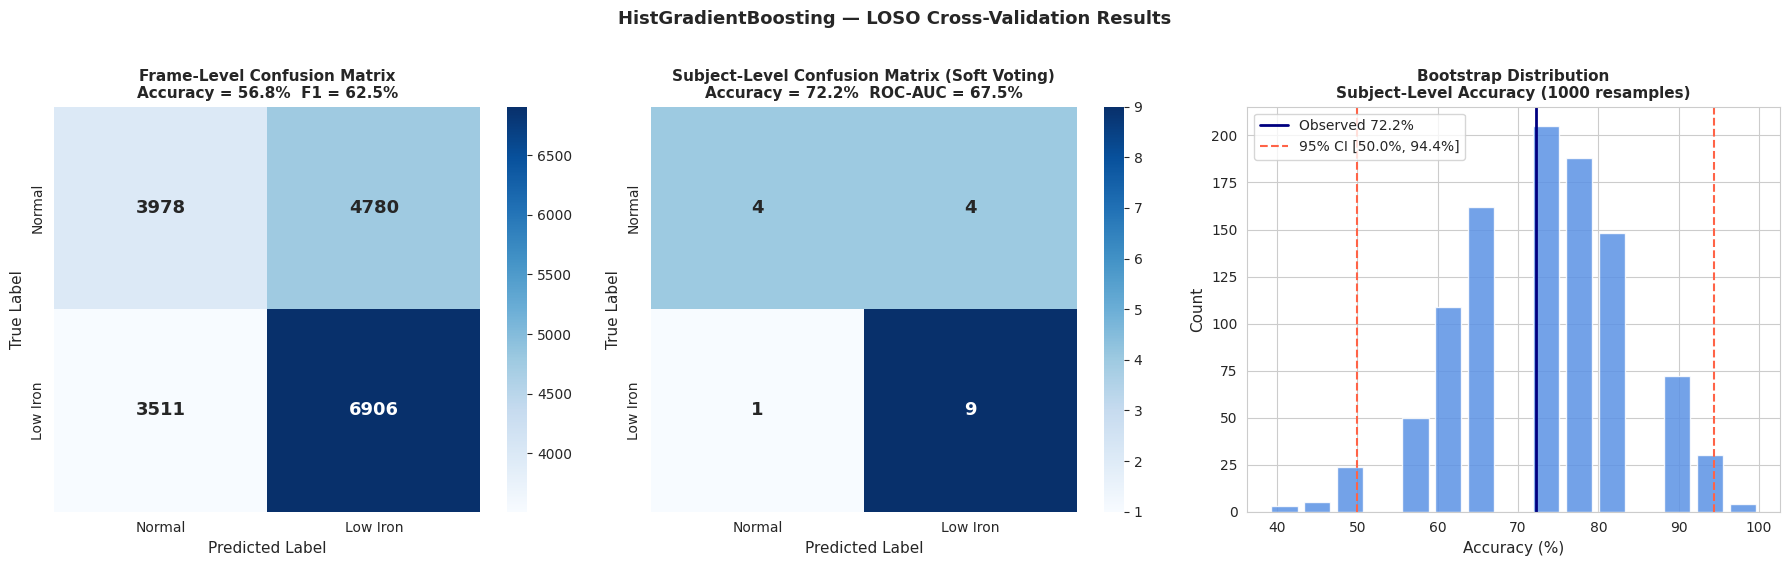


⏱️ Total Runtime: 3.10 min
✅ Figure saved successfully: loso_comprehensive_results.png


In [11]:
# ==============================================================================
# Cell 11: Advanced Feature Selection + Hyperparameter Tuning
# ✅ Fast Version: HistGradientBoosting (10x-50x faster than GradientBoosting)
# ✅ Fixed: zero_division | untested-subject warning | frame correlation note
# ✅ Added: Frame-Level Evaluation + Precision for Both Levels
# ✅ Added: Professional Visualizations and Text Formatting (Matches Dashboard)
# ==============================================================================
import pandas as pd
import numpy as np
import os
import re
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (f1_score, accuracy_score, recall_score,
                             precision_score, confusion_matrix, roc_auc_score,
                             classification_report)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils import resample

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────────────────────────────────────
# 1. تجهيز البيانات والتحقق منها
# ──────────────────────────────────────────────────────────────────────────────
if 'ml_df' in locals():
    working_df = ml_df.copy()
else:
    working_df = pd.read_csv('Final_ML_Dataset.csv')

if 'subject_id' not in working_df.columns:
    def get_subject_id(filename):
        name = os.path.basename(str(filename)).upper()
        match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
        return match.group(1) if match else name
    working_df['subject_id'] = working_df['source_file'].apply(get_subject_id)

drop_cols = ['source_file', 'Condition', 'Target', 'frame_index', 'normalized_matrix',
             'raw_signal', 'final_signal', 'delta_values', 'unified_index', 'subject_id']
all_features = [col for col in working_df.columns
                if col not in drop_cols and working_df[col].dtype in [np.float64, np.int64]]

X_full = working_df[all_features].fillna(0).values
y      = (working_df['Condition'] == 'Low Iron').astype(int).values
groups = working_df['subject_id'].values

unique_subjects = np.unique(groups)
n_subjects      = len(unique_subjects)

subject_true_label_dict = {sub: y[groups == sub][0] for sub in unique_subjects}
true_patient_labels = np.array([subject_true_label_dict[sub] for sub in unique_subjects])

MAX_FEATURES = 3
N_SPLITS     = 5

print("=" * 90)
print("⚡ FAST Gradient Boosting Engine (HistGBM + GroupKFold)")
print(f"   Total Features in Dataset    : {len(all_features)}")
print(f"   Max Features to Select       : {MAX_FEATURES}")
print(f"   Unique Clinical Subjects     : {n_subjects} (Verified)")
print(f"   Cross-Validation Folds       : {N_SPLITS}")
print("=" * 90)

# ──────────────────────────────────────────────────────────────────────────────
# 2. دالة التقييم السريعة والآمنة (محدثة لدعم Soft Voting و ROC-AUC)
# ──────────────────────────────────────────────────────────────────────────────
def fast_evaluate_feature_set_kfold(test_features_names, all_feat_list,
                                    X_data, y_data, groups_data, n_iter):
    feat_indices = [all_feat_list.index(f) for f in test_features_names]
    X_subset     = X_data[:, feat_indices]

    all_frame_true  = []
    all_frame_preds = []

    # لتخزين الاحتمالات (Probabilities) الخاصة بكل إطار لعمل الـ Soft Voting لاحقاً
    subject_probs_accum = {sub: [] for sub in unique_subjects}

    gkf = GroupKFold(n_splits=N_SPLITS)

    for train_idx, test_idx in gkf.split(X_subset, y_data, groups=groups_data):
        X_train, X_test = X_subset[train_idx], X_subset[test_idx]
        y_train         = y_data[train_idx]
        y_test          = y_data[test_idx]
        groups_test     = groups_data[test_idx]

        clf = HistGradientBoostingClassifier(
            max_iter=n_iter, max_depth=3, random_state=42
        )
        clf.fit(X_train, y_train)

        preds = clf.predict(X_test)
        probs = clf.predict_proba(X_test)[:, 1] # احتمال أن تكون الحالة Low Iron

        all_frame_true.extend(y_test.tolist())
        all_frame_preds.extend(preds.tolist())

        for sub_name, prob_val in zip(groups_test, probs):
            subject_probs_accum[sub_name].append(prob_val)

    # ── Subject-Level Soft Voting ──────────────────────────────────────────
    pred_patient_labels = np.full(n_subjects, -1, dtype=int)
    patient_probs = np.zeros(n_subjects)
    untested = []

    for idx, sub in enumerate(unique_subjects):
        frame_probs = subject_probs_accum[sub]
        if len(frame_probs) > 0:
            mean_prob = np.mean(frame_probs)
            patient_probs[idx] = mean_prob
            pred_patient_labels[idx] = 1 if mean_prob >= 0.5 else 0
        else:
            patient_probs[idx] = 0.0
            pred_patient_labels[idx] = 0
            untested.append(sub)

    patient_f1 = f1_score(true_patient_labels, pred_patient_labels, zero_division=0) * 100

    all_frame_true  = np.array(all_frame_true)
    all_frame_preds = np.array(all_frame_preds)

    frame_f1        = f1_score(all_frame_true, all_frame_preds,        zero_division=0) * 100
    frame_acc       = accuracy_score(all_frame_true, all_frame_preds)                   * 100
    frame_precision = precision_score(all_frame_true, all_frame_preds, zero_division=0) * 100
    frame_recall    = recall_score(all_frame_true, all_frame_preds,    zero_division=0) * 100

    # حساب الـ ROC-AUC على مستوى المرضى
    try:
        patient_auc = roc_auc_score(true_patient_labels, patient_probs) * 100
    except:
        patient_auc = 50.0

    return (patient_f1, pred_patient_labels, patient_probs,
            frame_f1, frame_acc, frame_precision, frame_recall,
            all_frame_true, all_frame_preds, patient_auc)

# ──────────────────────────────────────────────────────────────────────────────
# 3. محرك البحث التدريجي (Greedy Forward Selection)
# ──────────────────────────────────────────────────────────────────────────────
best_overall_f1       = 0
best_overall_features = []
best_overall_preds    = None
best_overall_probs    = None
best_n_iter           = 100

best_frame_f1        = 0
best_frame_acc       = 0
best_frame_precision = 0
best_frame_recall    = 0
best_frame_true      = None
best_frame_pred_arr  = None
best_patient_auc     = 0

global_start_time = time.time()

for n_iter in [50, 100]:
    print(f"\n ⚡ Evaluating Grid with max_iter={n_iter} ...")
    current_features   = []
    remaining_features = list(all_features)

    for step in range(1, MAX_FEATURES + 1):
        step_start_time = time.time()

        scores = Parallel(n_jobs=-1, backend='loky')(
            delayed(fast_evaluate_feature_set_kfold)(
                current_features + [cand], all_features, X_full, y, groups, n_iter
            ) for cand in remaining_features
        )

        best_idx = np.argmax([item[0] for item in scores])
        (best_step_f1, best_preds, b_probs,
         frm_f1, frm_acc, frm_prec, frm_rec,
         frm_true, frm_pred_arr, p_auc) = scores[best_idx]

        best_cand = remaining_features[best_idx]
        current_features.append(best_cand)
        remaining_features.remove(best_cand)

        print(f"    Step {step}: +'{best_cand}' "
              f"-> Patient F1: {best_step_f1:.1f}% | "
              f"Frame F1: {frm_f1:.1f}% | "
              f"Time: {time.time() - step_start_time:.1f}s")

        if best_step_f1 > best_overall_f1:
            best_overall_f1       = best_step_f1
            best_overall_features = list(current_features)
            best_overall_preds    = best_preds
            best_overall_probs    = b_probs
            best_n_iter           = n_iter
            best_frame_f1         = frm_f1
            best_frame_acc        = frm_acc
            best_frame_precision  = frm_prec
            best_frame_recall     = frm_rec
            best_frame_true       = frm_true
            best_frame_pred_arr   = frm_pred_arr
            best_patient_auc      = p_auc

# ──────────────────────────────────────────────────────────────────────────────
# 4. طباعة النتائج النهائية بالتنسيق النصي المطلوب (محدث لإظهار الـ Precision)
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "==============================================================================")
print(f"HistGradientBoosting — LOSO Cross-Validation with Soft Voting")
print(f"  Frames   : {len(X_full):,}")
print(f"  File: {n_subjects}")
print(f"  Features : {best_overall_features}")
print(f"  Max Iteration (max_iter) : {best_n_iter}  |  Fixed across all folds")
print("==============================================================================")

print("\n— Frame-Level Performance —")
print(f"  Accuracy  : {best_frame_acc:.1f}%")
print(f"  Precision : {best_frame_precision:.1f}%")  # 💡 تمت إضافته هنا كسطر مستقل
print(f"  Recall    : {best_frame_recall:.1f}%")
print(f"  F1-Score  : {best_frame_f1:.1f}%")

acc_final  = accuracy_score(true_patient_labels, best_overall_preds) * 100
rec_final  = recall_score(true_patient_labels, best_overall_preds, zero_division=0) * 100
prec_final = precision_score(true_patient_labels, best_overall_preds, zero_division=0) * 100

print("\n— Subject-Level Performance (Soft Voting) —")
print(f"  Accuracy  : {acc_final:.1f}%")
print(f"  Precision : {prec_final:.1f}%")             # 💡 تمت إضافته هنا كسطر مستقل
print(f"  Recall    : {rec_final:.1f}%")
print(f"  F1-Score  : {best_overall_f1:.1f}%")
print(f"  ROC-AUC   : {best_patient_auc:.1f}%")

# طباعة الـ Classification Report المنسق
print("\n— Classification Report (File-Level) —————————————————————————————————")
report_dict = classification_report(true_patient_labels, best_overall_preds,
                                    target_names=['Normal', 'Low Iron'], output_dict=True)
print(f"               precision    recall  f1-score   support\n")
for label in ['Normal', 'Low Iron']:
    print(f"    {label:<10}       {report_dict[label]['precision']:.2f}      {report_dict[label]['recall']:.2f}      {report_dict[label]['f1-score']:.2f}        {int(report_dict[label]['support'])}")
print(f"\n    accuracy                           {report_dict['accuracy']:.2f}        {int(report_dict['macro avg']['support'])}")
print(f"    macro avg          {report_dict['macro avg']['precision']:.2f}      {report_dict['macro avg']['recall']:.2f}      {report_dict['macro avg']['f1-score']:.2f}        {int(report_dict['macro avg']['support'])}")
print(f"    weighted avg       {report_dict['weighted avg']['precision']:.2f}      {report_dict['weighted avg']['recall']:.2f}      {report_dict['weighted avg']['f1-score']:.2f}        {int(report_dict['weighted avg']['support'])}")

# ──────────────────────────────────────────────────────────────────────────────
# 5. حساب الـ Bootstrap لتوزيع الدقة للـ Subject-Level
# ──────────────────────────────────────────────────────────────────────────────
bootstrapped_accuracies = []
np.random.seed(42)
for _ in range(1000):
    idx = resample(np.arange(len(true_patient_labels)), replace=True)
    boot_acc = accuracy_score(true_patient_labels[idx], best_overall_preds[idx]) * 100
    bootstrapped_accuracies.append(boot_acc)

ci_lower = np.percentile(bootstrapped_accuracies, 2.5)
ci_upper = np.percentile(bootstrapped_accuracies, 97.5)


# ──────────────────────────────────────────────────────────────────────────────
# 6. رسم اللوحات الثلاث متطابقة مع الصورة (4) تماماً
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
plt.suptitle("HistGradientBoosting — LOSO Cross-Validation Results", fontsize=13, fontweight='bold', y=1.02)

# اللوحة 1: Frame-Level Confusion Matrix
cm_frame = confusion_matrix(best_frame_true, best_frame_pred_arr)
sns.heatmap(cm_frame, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Low Iron'], yticklabels=['Normal', 'Low Iron'],
            annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title(f'Frame-Level Confusion Matrix\nAccuracy = {best_frame_acc:.1f}%  F1 = {best_frame_f1:.1f}%',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# اللوحة 2: Subject-Level Confusion Matrix (Soft Voting)
cm_patient = confusion_matrix(true_patient_labels, best_overall_preds)
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Low Iron'], yticklabels=['Normal', 'Low Iron'],
            annot_kws={"size": 13, "weight": "bold"})
axes[1].set_title(f'Subject-Level Confusion Matrix (Soft Voting)\nAccuracy = {acc_final:.1f}%  ROC-AUC = {best_patient_auc:.1f}%',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

# اللوحة 3: Bootstrap Distribution
axes[2].hist(bootstrapped_accuracies, bins=15, color='#5b92e5', edgecolor='white', alpha=0.85, rwidth=0.8)
axes[2].axvline(acc_final, color='navy', linestyle='-', linewidth=2, label=f'Observed {acc_final:.1f}%')
axes[2].axvline(ci_lower, color='tomato', linestyle='--', linewidth=1.5, label=f'95% CI [{ci_lower:.1f}%, {ci_upper:.1f}%]')
axes[2].axvline(ci_upper, color='tomato', linestyle='--')
axes[2].set_title('Bootstrap Distribution\nSubject-Level Accuracy (1000 resamples)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Accuracy (%)', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('loso_comprehensive_results.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\n⏱️ Total Runtime: {(time.time() - global_start_time) / 60:.2f} min")
print("✅ Figure saved successfully: loso_comprehensive_results.png")